# Session 2 — Lab

## Prompt sensitivity and structured generation

**Everything in this notebook is runnable as written.** You never have to write code from
scratch. Read the explanation, run the cell, read the result. Where a cell needs a decision
from you, it is marked **`>>> EDIT`** and tells you exactly what to change.

### Before you run anything

Open the **Lab Guide** alongside this notebook and do the pre-flight check for your operating
system. It takes ninety seconds and it catches the two problems that cost people the most time.

### What you will find out today

Last week you measured that the *same* prompt can give different answers. This week the
question is the other direction:

> **How much does changing the prompt — on purpose — move your result?**
>
> And is that more or less than the difference between two different models?

### The four checkpoints

| | |
|---|---|
| **A** | How often free-text output fails to parse |
| **B** | The same task with a fixed output schema |
| **C** | Accuracy across three prompts — the spread |
| **D** | Whether the model's stated confidence means anything |

### How long this takes

The core lab is about **168 model calls, mostly short outputs**. Measured against last week's
numbers:

| Your speed (Checkpoint A last week) | Generation time |
|---|---|
| ~10 tok/s | ~10 minutes |
| ~30 tok/s | ~3 minutes |
| ~80 tok/s | ~1 minute |

Part 0 measures your speed and tells you whether to attempt the optional sections.

---

## Part 0 — Pre-flight

### Step 0.1 — Imports

**What this does.** Loads the libraries. Same set as last week plus `re` for text matching.

**What you should see.** `imports ok`.

**If it fails.** Your notebook is running outside the project environment. Close it and
relaunch with `uv run jupyter lab` from inside the `aids-course` folder. (Lab Guide, pre-flight
step 1.)

In [1]:
import os
import re
import json
import time
import hashlib
import statistics
from collections import defaultdict

import httpx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("imports ok")

imports ok


### Step 0.2 — Connect to your model

**What this does.** Checks the server is running and that your model is installed.

**Why `/api/tags` first.** A clear error now ("you don't have that model") is much better than
a confusing one twenty minutes in.

**>>> EDIT if needed:** if you pulled something other than `qwen3:1.7b`, change the `MODEL`
line. `ollama list` in a terminal shows what you have.

**What you should see.** Your model listed, and `ready.`

**If you get a connection error.** Ollama is not running. Lab Guide, pre-flight step 2 — it has
the fix for each operating system.

In [2]:
OLLAMA = os.environ.get("OLLAMA_HOST", "http://127.0.0.1:11434")

# >>> EDIT THIS LINE if you use a different model <<<
MODEL = os.environ.get("COURSE_MODEL", "qwen3:1.7b")

try:
    r = httpx.get(f"{OLLAMA}/api/tags", timeout=10)
    available = [m["name"] for m in r.json().get("models", [])]
except Exception as e:
    available = []
    print("!! Could not reach Ollama:", e)
    print("!! See the Lab Guide, pre-flight step 2, for your operating system.")

print(f"server   : {OLLAMA}")
print(f"available: {available}")
print(f"using    : {MODEL}")

if available and MODEL not in available:
    print(f"\n!! {MODEL} is not installed. Either change MODEL above to one of the")
    print(f"!! names listed, or run in a terminal:  ollama pull {MODEL}")
elif available:
    print("\nready.")

server   : http://127.0.0.1:11434
available: ['qwen3:1.7b', 'qwen3:8b', 'qwen3:4b']
using    : qwen3:1.7b

ready.


### Step 0.3 — The call function

**What this does.** One function for every model call in this notebook.

**What changed since last week.** Two things.

**1. `fmt`.** If you pass a JSON schema to it, Ollama will *force* the output to match that
schema. That is the technique this whole session is about, and Part 2 explains it properly.
For now just note that it is there.

**2. `"think": False`.** `qwen3` is a **reasoning model**. Before it answers, it writes out a
private chain of thought. Ollama returns that separately, in `message.thinking`, and the actual
answer in `message.content`. This matters to us for a very practical reason: **the reasoning
comes out of the same token budget as the answer.** If you ask for 60 tokens and the model
spends all 60 thinking, `content` comes back as an empty string `''` and you get nothing —
having paid full price in time.

We do not want the reasoning. We want the label. So we switch it off. On the slowest laptop in
this cohort (~10 tok/s) this is the difference between roughly 6 seconds per call and roughly
60 — across the 168 calls in this notebook, that is the difference between a lab that finishes
and one that does not.

The function below also defends against the two ways this can still bite you:

- some model builds **ignore** `think: false` and write `<think>...</think>` inline into
  `content` anyway — so we strip it;
- some older Ollama builds **reject** the `think` field outright — so we detect that and retry
  without it.

**Also new, and unused until Part 3:** `top_p`, `top_k`, `min_p`. These are the other
sampling controls. Leave them alone for now — Part 3 sets them deliberately and explains what
each one does at that point.

**You do not need to modify this cell.** Run it and move on.

**What you should see.** `llm() ready` and nothing else.

In [3]:
import re

_THINK_OK = {"supported": True}   # flipped off if this Ollama build rejects the field


def _strip_think(text):
    """Remove inline reasoning.

    Some model builds ignore think:false and write their chain of thought into
    content inside <think>...</think>. An UNCLOSED <think> means the token
    budget ran out mid-thought, so there is no answer in there at all.
    """
    text = re.sub(r"<think>.*?</think>", "", text, flags=re.S)   # closed block
    if "</think>" in text:                     # stray closing tag
        text = text.split("</think>")[-1]
    if "<think>" in text:                      # never closed -> no answer
        text = text.split("<think>")[0]
    return text.strip()


def llm(prompt, model=MODEL, system=None, temperature=0.0, seed=42,
        fmt=None, max_tokens=200, base=OLLAMA, timeout=300.0,
        top_p=None, top_k=None, min_p=None, _retry=True):
    """One model call. Returns (text, metadata).

    fmt : None  -> free text, the model writes whatever it likes
          dict  -> a JSON Schema. Output is FORCED to match it.

    temperature / top_p / top_k / min_p : the sampling settings.
        Parts 1 and 2 leave these alone and run at temperature 0, because those
        parts are about the SHAPE of the output and a repeatable answer is
        easier to reason about. Part 3 sets them deliberately, and explains why.
        Anything left as None is simply not sent, so the server's default stands.
    """
    messages = []
    if system:
        messages.append({"role": "system", "content": system})
    messages.append({"role": "user", "content": prompt})

    options = {"temperature": temperature, "seed": seed, "num_predict": max_tokens}
    for name, value in (("top_p", top_p), ("top_k", top_k), ("min_p", min_p)):
        if value is not None:
            options[name] = value

    payload = {"model": model, "messages": messages, "stream": False, "options": options}
    if fmt is not None:
        payload["format"] = fmt              # <- the constrained-decoding switch
    if _THINK_OK["supported"]:
        payload["think"] = False             # <- don't spend the budget reasoning

    # everything needed to repeat this call, so the retries below stay readable
    kw = dict(model=model, system=system, temperature=temperature, seed=seed,
              fmt=fmt, max_tokens=max_tokens, base=base, timeout=timeout,
              top_p=top_p, top_k=top_k, min_p=min_p)

    t0 = time.perf_counter()
    r = httpx.post(f"{base}/api/chat", json=payload, timeout=timeout)

    # Older Ollama builds 400 on the unknown "think" field. Drop it and retry.
    if r.status_code >= 400 and _THINK_OK["supported"]:
        _THINK_OK["supported"] = False
        print("note: this Ollama build does not accept think:false - continuing without it")
        return llm(prompt, _retry=_retry, **kw)

    r.raise_for_status()
    d = r.json()
    wall = time.perf_counter() - t0
    msg = d.get("message", {})
    content = _strip_think(msg.get("content") or "")

    # Empty content = the model ignored think:false and thought until the budget
    # ran out. Retry once with room to finish, so the lab keeps moving.
    if not content and _retry:
        kw["max_tokens"] = max(max_tokens * 6, 600)
        return llm(prompt, _retry=False, **kw)

    if not content:
        raise RuntimeError(
            "The model returned an empty answer: it used its whole token budget "
            "on reasoning and never got to the answer.\n"
            f"  thinking field: {len(msg.get('thinking') or '')} chars\n"
            "  Fix: raise max_tokens, or switch MODEL to a non-reasoning model "
            "such as llama3.2:1b. See LAB-GUIDE troubleshooting T-7."
        )

    return content, {
        "wall_s": wall,
        "out_tokens": d.get("eval_count") or 0,
        "tok_per_s": (d.get("eval_count") or 0) / wall if wall else 0.0,
    }


print("llm() ready")

llm() ready


### Step 0.4 — Measure your speed properly

**What this does.** Two calls. The first is thrown away; the second is timed.

**Why throw the first one away — and this is worth reading.**

Last week `doctor.py` timed a single call and the notebook timed three. Across the cohort
those two numbers disagreed by as much as **32×**. One person's `doctor.py` said 0.7 tok/s
while their notebook said 22.8.

The reason: the very first call has to load the model from disk into memory, and that time was
being counted as generation time. So `doctor.py` was mostly measuring *disk speed*.

**That was an error in my script, not in anyone's machine** — and it is a clean example of this
week's theme. The same quantity, measured two ways, gave answers differing by a factor of
thirty. Which number is "the throughput" depends entirely on the procedure that produced it.

So: warm up first, then measure.

**What you should see.** A cold figure, a warm figure, and a time estimate for the lab.

In [4]:
print("warming up (this call is discarded — it pays the model-loading cost)...")
_, cold = llm("Say ready.", max_tokens=32)
print(f"  cold: {cold['tok_per_s']:5.1f} tok/s   ({cold['wall_s']:.1f}s)")

_, warm = llm("Count from 1 to 40, comma separated.", max_tokens=120)
SPEED = warm["tok_per_s"]
print(f"  warm: {SPEED:5.1f} tok/s   ({warm['wall_s']:.1f}s)")

if cold["tok_per_s"] > 0:
    print(f"\n  ratio: {SPEED / cold['tok_per_s']:.1f}x")

est = 168 * 44 / SPEED / 60 if SPEED else 0
print(f"\nEstimated generation time for the core lab: {est:.0f} minutes")
RUN_OPTIONAL = True
print("Optional sections:", "attempt them" if RUN_OPTIONAL else
      "SKIP them — your machine is better used on the core lab")

warming up (this call is discarded — it pays the model-loading cost)...
  cold:   4.6 tok/s   (5.2s)
  warm:  19.4 tok/s   (5.7s)

  ratio: 4.2x

Estimated generation time for the core lab: 6 minutes
Optional sections: attempt them


---

## Part 1 — The task, and the problem with free text

### Step 1.1 — The dataset

**What this does.** Loads 20 hand-labelled sentences.

**The task.** Each sentence comes from something like a paper abstract. Decide whether it makes
a **causal** claim (X *produces a change in* Y) or an **associational** one (X and Y are
*related*, with no claim about production).

**Why this task.** Three reasons:

1. It is a real annotation problem in your own world — overstated causal language is something
   reviewers actually look for.
2. It is genuinely hard at the boundary. Competent annotators disagree. The five items marked
   `hard = 1` are ones where you might reasonably disagree with my label.
3. Because you have opinions about it, you will notice when the model is wrong in an
   interesting way rather than just recording a number.

**What you should see.** A count, a label balance, and the first few rows.

**20 items is not many** — and you will see the consequence in Part 3, where the confidence
intervals come out wide. That is deliberate. Week 10 is about how many items you actually need.

In [5]:
DATA = [
 # sentence, label, hard
 ("Smoking causes lung cancer in susceptible individuals.", "causal", 0),
 ("Higher income was associated with longer life expectancy.", "assoc", 0),
 ("The intervention reduced hospital readmissions by 12%.", "causal", 0),
 ("Patients taking the drug had lower mortality rates.", "assoc", 1),
 ("We find that minimum wage increases lead to modest employment losses.", "causal", 0),
 ("Regions with more doctors report better health outcomes.", "assoc", 0),
 ("Randomised assignment to tutoring improved test scores by 0.3 SD.", "causal", 0),
 ("Test scores correlate strongly with household income.", "assoc", 0),
 ("Exposure to lead impairs cognitive development.", "causal", 0),
 ("Children in older housing show lower cognitive scores.", "assoc", 0),
 ("Vitamin D supplementation had no effect on fracture risk.", "causal", 0),
 ("Low vitamin D levels predict higher fracture risk.", "assoc", 0),
 ("Removing the subsidy decreased consumption.", "causal", 0),
 ("Consumption declined after the subsidy was removed.", "assoc", 1),
 ("The mutation confers resistance to the antibiotic.", "causal", 0),
 ("Resistant strains more frequently carry the mutation.", "assoc", 0),
 ("Early screening reduces mortality from the disease.", "causal", 0),
 ("Screened patients survive longer on average.", "assoc", 1),
 ("The fertiliser increased yield in the field trial.", "causal", 0),
 ("Yield was higher on fertilised plots.", "assoc", 1),
]

df = pd.DataFrame(DATA, columns=["sentence", "label", "hard"])
print(f"{len(df)} items | {df.label.value_counts().to_dict()} | {df.hard.sum()} marked hard")
df.head(4)

20 items | {'causal': 10, 'assoc': 10} | 4 marked hard


,sentence,label,hard
0,Smoking causes lung cancer in susceptible indi...,causal,0
1,Higher income was associated with longer life ...,assoc,0
2,The intervention reduced hospital readmissions...,causal,0
3,Patients taking the drug had lower mortality r...,assoc,1


### Step 1.2 — Ask the model, in plain English

**What this does.** Sends each of the 20 sentences with the prompt almost everyone writes
first, and stores the raw text that comes back.

**Read the prompt before you run it.** It asks the question and says nothing about the format
of the answer. That is the point: it is what you write when you are thinking about the *task*
and have not yet thought about the *pipeline*.

**What you should see.** A progress counter, then the first few raw replies — in prose. Some
will be a paragraph. Some will hedge. Some will answer a slightly different question. None of
that is a malfunction; you did not ask for anything narrower.

**How long.** 20 calls. About 3 minutes at 10 tok/s, well under a minute at 30.

In [6]:
PROMPT_V1 = (
    "Is this sentence making a causal claim or an associational claim?\n"
    "Answer in one word.\n\n"
    "Sentence: {s}"
)

raw_v1 = []
for i, r in enumerate(df.itertuples(), 1):
    txt, _ = llm(PROMPT_V1.format(s=r.sentence), max_tokens=160)
    raw_v1.append(txt)
    print(f"  {i}/{len(df)}", end="\r", flush=True)
print(f"\ndone — {len(raw_v1)} replies\n")

for s, t in list(zip(df.sentence, raw_v1))[:5]:
    print(f"  {s[:46]:48s} -> {t.strip()[:88]!r}")

  20/20
done — 20 replies

  Smoking causes lung cancer in susceptible indi   -> 'Causal'
  Higher income was associated with longer life    -> 'Associational'
  The intervention reduced hospital readmissions   -> 'Causal.'
  Patients taking the drug had lower mortality r   -> 'Causal'
  We find that minimum wage increases lead to mo   -> 'Causal'


### Step 1.3 — Now try to actually use those answers

**What this does.** Tries to turn each reply into a usable label, and counts the failures.

**This is the point of Part 1.** You asked for one word. Look at what you have to write to
cope with what came back: the model may reply `causal`, `Causal.`, `**assoc**`, `The answer is
causal`, a full sentence of reasoning, or something that contains both words.

Every line of `parse()` below exists because some model, somewhere, did that thing. This is
what "just parse the output" turns into within a week of real use, and it is a **silent**
failure mode — a parser that returns `None` for 15% of your data biases your results and
nothing in your pipeline complains.

**What you should see.** An accuracy figure and — more importantly — a count of replies that
could not be parsed at all.

**Your parse-failure count is Checkpoint A.**

In [7]:
def parse(out):
    """Turn a free-text reply into 'causal', 'assoc', or None. Best effort."""
    t = out.strip().lower()
    t = t.replace("*", "").replace("`", "")
    if "answer:" in t:
        t = t.split("answer:")[-1]
    t = t.strip().strip(".").strip()
    head = t[:60]
    has_c = "causal" in head
    has_a = ("assoc" in head) or ("correlat" in head)
    if has_c and not has_a: return "causal"
    if has_a and not has_c: return "assoc"
    if t.startswith("causal"): return "causal"
    if t.startswith("assoc"):  return "assoc"
    return None                      # <- gave up

pred_v1 = [parse(t) for t in raw_v1]
n_fail = sum(p is None for p in pred_v1)
ok = [(p, g) for p, g in zip(pred_v1, df.label) if p is not None]
acc_v1 = sum(p == g for p, g in ok) / len(ok) if ok else 0.0

print("=" * 58)
print("  CHECKPOINT A — free-text output")
print("=" * 58)
print(f"  replies that could not be parsed : {n_fail} / {len(df)}  ({n_fail/len(df):.0%})")
print(f"  accuracy on the ones that parsed : {acc_v1:.2f}  (n={len(ok)})")
print("=" * 58)

if n_fail:
    print("\n  examples of what defeated the parser:")
    for t, p in zip(raw_v1, pred_v1):
        if p is None:
            print(f"    {t.strip()[:90]!r}")
if n_fail == 0:
    print("\n  Zero failures. Before you conclude the problem is imaginary:")
    print("  that is a fact about THIS model, THIS prompt and THIS version.")
    print("  You did not verify it — you got lucky, and you would not know")
    print("  the day it stopped being true except by parsing and hoping.")

print("\n  ^ post the parse-failure count to the shared sheet")

  CHECKPOINT A — free-text output
  replies that could not be parsed : 0 / 20  (0%)
  accuracy on the ones that parsed : 0.75  (n=20)

  Zero failures. Before you conclude the problem is imaginary:
  that is a fact about THIS model, THIS prompt and THIS version.
  You did not verify it — you got lucky, and you would not know
  the day it stopped being true except by parsing and hoping.

  ^ post the parse-failure count to the shared sheet


### Step 1.4 — "Just tell it to answer in one word"

That is the right objection, and it is what everyone tries next. So test it rather than
assuming — six items, one strict prompt.

**What you should see.** Mostly clean one-word replies. On a well-behaved instruction-tuned
model this often works perfectly, and your parse-failure count here may well be zero.

**So why not stop here?** Three reasons, and the third is the one that matters:

1. **You did not verify it, you observed it.** Nothing enforced the format. A model update, a
   different quantisation, a longer sentence, and the guarantee you never had disappears.
2. **Failure is silent.** The parser returns `None` and your row vanishes from the denominator.
3. **It does not scale past one word.** In ten minutes you will want a label *and* a
   confidence *and* the phrase the model keyed on. There is no phrasing of "please reply in
   exactly one word" that reliably yields three typed fields.

Part 2 is what you do instead of getting lucky.

In [8]:
PROMPT_STRICT = (
    "Is this sentence making a causal claim or an associational claim?\n"
    "Answer with exactly one word: causal or assoc.\n\n"
    "Sentence: {s}"
)

probe = df.head(6)
raw_strict = [llm(PROMPT_STRICT.format(s=r.sentence), max_tokens=60)[0]
              for r in probe.itertuples()]

print("  strict prompt, 6 items\n")
for s, t in zip(probe.sentence, raw_strict):
    print(f"  {s[:44]:46s} -> {t.strip()[:40]!r}")

fail_strict = sum(parse(t) is None for t in raw_strict)
print(f"\n  unparseable: {fail_strict} / {len(probe)}")
print("  (compare with Checkpoint A above — then read why this is still not enough)")

  strict prompt, 6 items

  Smoking causes lung cancer in susceptible in   -> 'causal'
  Higher income was associated with longer lif   -> 'assoc'
  The intervention reduced hospital readmissio   -> 'assoc'
  Patients taking the drug had lower mortality   -> 'assoc'
  We find that minimum wage increases lead to    -> 'assoc'
  Regions with more doctors report better heal   -> 'assoc'

  unparseable: 0 / 6
  (compare with Checkpoint A above — then read why this is still not enough)


> **Note the second number carefully.** "Accuracy on the ones that parsed" is a
> **conditional** accuracy — it silently drops the failures. If the items that fail to parse are
> the hard ones, and they usually are, that number is optimistic. You have introduced a
> selection effect into your own evaluation without meaning to.
>
> This is exactly the kind of thing you would catch immediately in someone else's survey
> analysis.

---

## Part 2 — Structured generation

### Step 2.1 — What a JSON schema is

**The idea.** Instead of asking nicely for a format and hoping, you *describe the shape of the
answer* and the software makes it impossible for the model to produce anything else.

A **JSON Schema** is a dictionary describing a JSON object: which fields exist, what type each
one is, and — the important part — which values are permitted.

Read the schema below. The key line is `"enum": ["causal", "assoc"]`. That says the `label`
field may contain *only* those two strings. Not `Causal`, not `causal.`, not a sentence.

**How it works underneath** (one paragraph, and it is worth having):

At each step the model produces a score for every token. Normally you pick from all of them.
With a schema, the runtime computes which tokens could still lead to a valid document and sets
every other token's probability to zero before choosing. So invalid output is not discouraged —
it is **unreachable**. This is called *constrained decoding*.

**What a schema does _not_ enforce — and you will see this in your own data.**

The grammar constrains **structure and type**: which fields exist, that `label` is one of two
exact strings, that `confidence` is a number. It does **not** enforce `minimum` and `maximum`.
Those are *validation* keywords — a checker uses them after the fact; the decoder ignores them.

So `confidence` is guaranteed to be present and guaranteed to be a number, but **not**
guaranteed to be in [0, 1]. Some calls come back with `0.95` and others with `95`, and if you
average those together you get a meaningless number. The notebook normalises with `conf01()`
below, and Part 4 tells you how many of your calls needed it.

Hold onto the general shape of this, because it recurs: **a constraint removes the failure
modes it covers and none of the ones it does not.** Read any schema and ask which fields are
actually pinned down. Here `label` is completely pinned, `confidence` is half-pinned, and `cue`
is free text that could be anything at all.

**Why this matters more than it sounds.** It turns the model from something that writes prose
into an **instrument with a fixed output space**. That is what makes it usable for measurement,
and it is why every remaining session in this course uses it.

**What you should see.** The schema printed back, and a short explanation of each field.

In [9]:
SCHEMA = {
    "type": "object",
    "properties": {
        "label": {
            "type": "string",
            "enum": ["causal", "assoc"],          # <- ONLY these two values are possible
        },
        "confidence": {
            "type": "number",
            "minimum": 0,
            "maximum": 1,
        },
        "cue": {
            "type": "string",
            "description": "the word or phrase that decided it",
        },
    },
    "required": ["label", "confidence", "cue"],
}


def conf01(x):
    """Put a stated confidence onto [0, 1].

    The schema pins the TYPE (number) but not the BOUNDS, so models answer on
    whichever scale they feel like: 0.95 from one call, 95 from the next.
    Averaging those together is meaningless, so normalise at parse time —
    every confidence in this notebook goes through here.
    """
    try:
        v = float(x)
    except (TypeError, ValueError):
        return np.nan
    if np.isnan(v):
        return np.nan
    if v > 1.0:                      # answered on a 0-100 scale
        v = v / 100.0
    return min(max(v, 0.0), 1.0)


print(json.dumps(SCHEMA, indent=2))
print()
print("label      : must be exactly 'causal' or 'assoc'. Nothing else can be generated.")
print("confidence : a number. NOTE: minimum/maximum are not enforced by the")
print("             decoder — only the type is. conf01() normalises it.")
print("cue        : free text — the span the model says decided it. This is for auditing:")
print("             when it is wrong, the cue usually tells you why.")

{
  "type": "object",
  "properties": {
    "label": {
      "type": "string",
      "enum": [
        "causal",
        "assoc"
      ]
    },
    "confidence": {
      "type": "number",
      "minimum": 0,
      "maximum": 1
    },
    "cue": {
      "type": "string",
      "description": "the word or phrase that decided it"
    }
  },
  "required": [
    "label",
    "confidence",
    "cue"
  ]
}

label      : must be exactly 'causal' or 'assoc'. Nothing else can be generated.
confidence : a number. NOTE: minimum/maximum are not enforced by the
             decoder — only the type is. conf01() normalises it.
cue        : free text — the span the model says decided it. This is for auditing:
             when it is wrong, the cue usually tells you why.


### Step 2.2 — Run the same task with the schema

**What this does.** Same 20 sentences, same instruction, but with `fmt=SCHEMA` passed to `llm()`.

**The only difference** from Step 1.2 is that one argument.

**What you should see.** A progress counter, then a proper dataframe — typed columns, no
parsing, nothing to clean.

**How long.** 20 calls, roughly the same as Step 1.2.

In [10]:
PROMPT_STRUCT = (
    "A CAUSAL claim asserts that one thing produces a change in another.\n"
    "An ASSOCIATIONAL claim reports a relationship without asserting production.\n\n"
    "Classify the sentence. Report the cue word that decided it, and your confidence.\n\n"
    "Sentence: {s}"
)

rows, schema_fails = [], 0
for i, r in enumerate(df.itertuples(), 1):
    txt, _ = llm(PROMPT_STRUCT.format(s=r.sentence), fmt=SCHEMA, max_tokens=120)
    try:
        o = json.loads(txt)
        rows.append({"sentence": r.sentence, "gold": r.label, "hard": r.hard,
                     "pred": o["label"], "conf": conf01(o["confidence"]),
                     "conf_raw": o["confidence"],
                     "cue": str(o.get("cue", ""))[:40]})
    except Exception:
        schema_fails += 1
        rows.append({"sentence": r.sentence, "gold": r.label, "hard": r.hard,
                     "pred": None, "conf": np.nan, "conf_raw": np.nan, "cue": ""})
    print(f"  {i}/{len(df)}", end="\r", flush=True)

st = pd.DataFrame(rows)
st["correct"] = st.pred == st.gold
_rs = int((pd.to_numeric(st.conf_raw, errors="coerce") > 1.0).sum())
print(f"\ndone")
if _rs:
    print(f"  ({_rs} of {len(st)} answered confidence on a 0-100 scale — normalised)")
print()
st.head(6)[["sentence", "gold", "pred", "conf", "cue"]]

  20/20
done
  (1 of 20 answered confidence on a 0-100 scale — normalised)



,sentence,gold,pred,conf,cue
0,Smoking causes lung cancer in susceptible indi...,causal,causal,1.00,causes
1,Higher income was associated with longer life ...,assoc,assoc,0.95,associated
2,The intervention reduced hospital readmissions...,causal,causal,0.95,reduced hospital readmissions by 12%
3,Patients taking the drug had lower mortality r...,assoc,assoc,0.80,lower mortality rates
4,We find that minimum wage increases lead to mo...,causal,assoc,0.85,lead to
5,Regions with more doctors report better health...,assoc,assoc,0.80,report better health outcomes


### Step 2.3 — ✅ CHECKPOINT B

**What this does.** Compares free text against structured output on the one thing that is not
about accuracy at all: **did you get usable data?**

**What you should see.** Parse failures at or near zero for the structured run.

**Post both parse-failure counts to the shared sheet.**

In [11]:
acc_struct = st.correct.mean()

print("=" * 58)
print("  CHECKPOINT B — free text vs. fixed schema")
print("=" * 58)
print(f"  {'':22s} {'unusable':>10s} {'accuracy':>10s}")
print(f"  {'free text (Part 1)':22s} {n_fail:>7d}/{len(df)} {acc_v1:>10.2f}")
print(f"  {'schema (Part 2)':22s} {schema_fails:>7d}/{len(df)} {acc_struct:>10.2f}")
print("=" * 58)
print()
print("  The accuracy numbers are similar — the schema does not make the model")
print("  smarter. What it removes is the parsing layer, and with it an entire")
print("  category of silent failure.")
print("\n  ^ post both unusable-counts to the shared sheet")

  CHECKPOINT B — free text vs. fixed schema
                           unusable   accuracy
  free text (Part 1)           0/20       0.75
  schema (Part 2)              0/20       0.85

  The accuracy numbers are similar — the schema does not make the model
  smarter. What it removes is the parsing layer, and with it an entire
  category of silent failure.

  ^ post both unusable-counts to the shared sheet


### Step 2.4 — The `cue` field earns its place

**What this does.** Shows what the model said it keyed on, split by whether it was right.

**Why include a field like this at all.** A label on its own is not auditable — when it is
wrong you have no idea why. One extra field that costs a few tokens turns "the model got it
wrong" into "the model keyed on the word *predict*, which it treats as causal."

**This is a habit worth taking to your own work.** Whenever you use a model to produce data,
have it also emit the evidence it used.

**What you should see.** Two lists of cue words.

In [12]:
good = st[st.correct & st.pred.notna()]
bad  = st[(~st.correct) & st.pred.notna()]

print(f"cues on CORRECT predictions (n={len(good)}):")
print(good.cue.str.lower().str.strip().value_counts().head(8).to_string() or "  (none)")

print(f"\ncues on INCORRECT predictions (n={len(bad)}):")
if len(bad):
    for _, r in bad.iterrows():
        print(f"  gold={r.gold:6s} pred={str(r.pred):6s} cue={r.cue!r}")
        print(f"     {r.sentence[:80]}")
else:
    print("  none — the model got all 20 right")

cues on CORRECT predictions (n=17):
cue
causes                                  1
associated                              1
reduced hospital readmissions by 12%    1
lower mortality rates                   1
report better health outcomes           1
improved test scores by 0.3 sd          1
correlate strongly with                 1
impairs                                 1

cues on INCORRECT predictions (n=3):
  gold=causal pred=assoc  cue='lead to'
     We find that minimum wage increases lead to modest employment losses.
  gold=causal pred=assoc  cue='no effect on fracture risk'
     Vitamin D supplementation had no effect on fracture risk.
  gold=assoc  pred=causal cue='declined after the subsidy was removed'
     Consumption declined after the subsidy was removed.


---

## Part 3 — Does the prompt change the answer?

### Step 3.1 — Three prompts that a competent person might write

**What this does.** Defines three instructions for the same task.

**Read them.** They differ in framing, not in meaning:

- **`bare`** — asks the question, no definitions.
- **`defined`** — supplies definitions of the two categories. (This is the Part 2 prompt.)
- **`role`** — casts the model as a methodologist reviewing manuscripts.

**None of these is a trick or a straw man.** All three are things a careful researcher might
write on a Tuesday afternoon. That is the point: if the choice between them moves your result,
then it is an uncontrolled variable in your study.

**What you should see.** The three prompts printed.

In [13]:
PROMPTS = {
 "bare": (
   "Is this sentence making a causal claim or an associational claim?\n"
   "Report your answer, the cue that decided it, and your confidence.\n\n"
   "Sentence: {s}"
 ),
 "defined": PROMPT_STRUCT,
 "role": (
   "You are a methodologist reviewing manuscripts for overstated causal language.\n"
   "Classify the sentence as causal or assoc. Report the cue that decided it and "
   "your confidence.\n\n"
   "Sentence: {s}"
 ),
}

for name, p in PROMPTS.items():
    print(f"--- {name} " + "-" * (50 - len(name)))
    print(p.format(s="<sentence goes here>"))
    print()

--- bare ----------------------------------------------
Is this sentence making a causal claim or an associational claim?
Report your answer, the cue that decided it, and your confidence.

Sentence: <sentence goes here>

--- defined -------------------------------------------
A CAUSAL claim asserts that one thing produces a change in another.
An ASSOCIATIONAL claim reports a relationship without asserting production.

Classify the sentence. Report the cue word that decided it, and your confidence.

Sentence: <sentence goes here>

--- role ----------------------------------------------
You are a methodologist reviewing manuscripts for overstated causal language.
Classify the sentence as causal or assoc. Report the cue that decided it and your confidence.

Sentence: <sentence goes here>



### Step 3.2 — Run the grid

**What this does.** Every prompt × every seed × every sentence. 3 × 2 × 20 = **120 calls**.

**Why the temperature changes here — read this, it is the point of the step.**

Parts 1 and 2 ran at `temperature = 0`. That is **greedy decoding**: at every position the
model takes the single most likely token. It is repeatable, which is what you want when the
question is about the *shape* of the output.

But it makes the seed **meaningless**. A seed only does something when something is being
sampled, and at temperature 0 nothing is — you established exactly this last week. So if we
ran this grid at temperature 0, the seed spread would come back as approximately zero, and it
would be zero *by construction*. We would not have measured a small effect. We would have
removed the thing we claimed to be measuring and then reported its absence as a finding.

**A null that is zero by construction proves nothing.** If you take one methodological habit
out of today, take that one.

So Part 3 runs at the sampling settings Qwen publishes for this model in non-thinking mode —
`temperature 0.7, top_p 0.8, top_k 20`. Now the seed spread is a real quantity: **how far your
accuracy moves when nothing changes except the random draw.** That is the honest yardstick for
the prompt effect.

**What the three knobs do:**

| | |
|---|---|
| `temperature` | Divides the logits before the softmax. Below 1 sharpens the distribution, above 1 flattens it. At 0 it collapses to argmax |
| `top_k` | Keep only the `k` highest-probability tokens, renormalise, then sample |
| `top_p` | Keep the smallest set of tokens whose probabilities sum to `p` ("nucleus"), renormalise, then sample |

`top_k` and `top_p` are both truncation rules: they delete the long tail of implausible tokens
before sampling, so raising temperature adds variety without admitting nonsense.

**Why two seeds.** Budget. Two seeds give you a range of two numbers, which **understates** the
true sampling spread — treat what you get as a floor, not an estimate. Say so if you report it.

**Why the schema.** Every call is constrained, so there is no parsing and no missing data. The
comparison is clean.

**Why results are cached to disk.** If your kernel dies, re-running this cell will not repeat
the work. Delete `w2_grid.csv` to force a fresh run. It is a plain CSV, so you can open it in a
spreadsheet and look.

**How long.** 120 calls: about **8 minutes at 10 tok/s**, 2–3 minutes at 30 tok/s. Start it and
read the next markdown cell while it runs.

**What you should see.** A progress counter, then a shape and a missing-value count of zero.

In [14]:
CACHE = "w2_grid.csv"   # CSV, not parquet — no extra package needed
SEEDS = [0, 1]

# Qwen's published settings for this model in NON-thinking mode. We sample here
# on purpose: at temperature 0 the seed does nothing and the null is fake.
SAMPLING = dict(temperature=0.7, top_p=0.8, top_k=20)

grid = None
if os.path.exists(CACHE):
    cached = pd.read_csv(CACHE)
    # A cache is only valid for the settings that produced it. Silently reusing
    # results from a different configuration is its own small reproducibility
    # disaster, so check rather than hope.
    same = ("temp" in cached.columns
            and float(cached.temp.iloc[0]) == SAMPLING["temperature"])
    if same:
        grid = cached
        # Older cache files stored the raw stated confidence, on whatever scale
        # the model chose. Normalise on load so a cached run and a fresh run
        # give the same numbers.
        src = grid["conf_raw"] if "conf_raw" in grid.columns else grid["conf"]
        grid["conf_raw"] = src
        grid["conf"] = [conf01(v) for v in src]
        print(f"loaded cached results from {CACHE}  (delete the file to force a re-run)")
    else:
        print(f"{CACHE} was produced with different sampling settings — re-running")

if grid is None:
    recs, n, total = [], 0, len(PROMPTS) * len(SEEDS) * len(df)
    t0 = time.time()
    for pname, tmpl in PROMPTS.items():
        for seed in SEEDS:
            for r in df.itertuples():
                txt, _ = llm(tmpl.format(s=r.sentence), seed=seed, fmt=SCHEMA,
                             max_tokens=120, **SAMPLING)
                try:
                    o = json.loads(txt)
                    pred = o["label"]
                    conf_raw = o["confidence"]          # what the model actually said
                    conf = conf01(conf_raw)             # on [0, 1], always
                except Exception:
                    pred, conf, conf_raw = None, np.nan, np.nan
                recs.append({"prompt": pname, "seed": seed, "sentence": r.sentence,
                             "gold": r.label, "hard": r.hard, "pred": pred, "conf": conf,
                             "conf_raw": conf_raw,
                             "temp": SAMPLING["temperature"]})
                n += 1
                if n % 10 == 0:
                    el = time.time() - t0
                    print(f"  {n}/{total}   {el:.0f}s elapsed, ~{el/n*(total-n):.0f}s left",
                          end="\r", flush=True)
    grid = pd.DataFrame(recs)
    grid.to_csv(CACHE, index=False)
    print(f"\ndone in {time.time()-t0:.0f}s")

grid["correct"] = grid.pred == grid.gold
print(f"\nshape: {grid.shape} | unusable: {grid.pred.isna().sum()}")
print(f"sampling: {SAMPLING}")

loaded cached results from w2_grid.csv  (delete the file to force a re-run)

shape: (120, 10) | unusable: 1
sampling: {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20}


### Step 3.3 — Two spreads, side by side

**What this does.** Computes accuracy for each (prompt, seed) cell, then compares:

- the **prompt spread** — best prompt minus worst prompt
- the **seed spread** — for a fixed prompt, seed 0 versus seed 1

**How to read it.** The seed spread is your **null**, and it is now a real one. Nothing about
the task, the prompt or the data changed between those two runs — only the random draw. So it
tells you how much this number moves for no reason at all. That is the noise floor of your
measurement.

The prompt spread is the effect of a choice you made deliberately, and would almost certainly
not report in a paper.

**The comparison that matters.** If the prompt spread is not comfortably larger than the seed
spread, you cannot claim the prompt did anything — you are reading noise. If it is larger, then
prompt phrasing is a real experimental factor in any study using this method, and an
unreported one.

**Either result is a finding.** Do not go hunting for the answer you expected.

**What you should see.** A small table and two spread numbers. With two seeds and twenty items
both are noisy — that is the honest situation, and Step 3.4 puts intervals on it.

In [15]:
cell = (grid.groupby(["prompt", "seed"]).correct.mean()
            .unstack("seed").round(3))
cell.columns = [f"seed {c}" for c in cell.columns]
cell["mean"] = cell.mean(axis=1).round(3)
print(cell.to_string())

by_prompt   = grid.groupby("prompt").correct.mean()
PROMPT_SPREAD = by_prompt.max() - by_prompt.min()
seed_spreads  = (grid.groupby(["prompt", "seed"]).correct.mean()
                     .groupby("prompt").agg(lambda s: s.max() - s.min()))
SEED_SPREAD   = seed_spreads.max()

print(f"\nbest prompt  : {by_prompt.idxmax()}  ({by_prompt.max():.3f})")
print(f"worst prompt : {by_prompt.idxmin()}  ({by_prompt.min():.3f})")
print(f"\nspread across PROMPTS : {PROMPT_SPREAD:.3f}")
print(f"spread across SEEDS   : {SEED_SPREAD:.3f}   <- the null (sampling noise)")

if SEED_SPREAD > 0:
    print(f"\nratio prompt/seed     : {PROMPT_SPREAD / SEED_SPREAD:.2f}")
    print("  (a ratio near 1 means the prompt effect is indistinguishable from noise)")
else:
    print("\nSeed spread came out exactly 0. With only two seeds that is possible")
    print("even when the true sampling noise is not zero — you have one comparison,")
    print("not a distribution. Report it as 'below what two seeds can resolve'.")


         seed 0  seed 1   mean
prompt                        
bare       0.60    0.55  0.575
defined    0.85    0.85  0.850
role       0.80    0.75  0.775

best prompt  : defined  (0.850)
worst prompt : bare  (0.575)

spread across PROMPTS : 0.275
spread across SEEDS   : 0.050   <- the null (sampling noise)

ratio prompt/seed     : 5.50
  (a ratio near 1 means the prompt effect is indistinguishable from noise)


### Step 3.4 — Put an interval on it

**What this does.** A bootstrap confidence interval for each prompt's accuracy.

**What a bootstrap does, in one sentence.** Resample your 20 items with replacement a few
thousand times, recompute accuracy each time, and take the middle 95% of the resulting values —
that range is how much your estimate would wobble if you had drawn a different 20 items.

**Why this cell exists.** Because a bare difference between two accuracies is not a finding.
With only 20 items these intervals will be **wide** — probably wide enough that the prompts
overlap heavily.

**That is the honest result, and it is the point.** You cannot distinguish the prompts at this
sample size. Week 10 covers how many items you would actually need.

**What you should see.** Three intervals, and a note about whether they overlap.

In [16]:
def boot_ci(x, n=4000, seed=0):
    x = np.asarray(x, dtype=float)
    rng = np.random.default_rng(seed)
    means = rng.choice(x, size=(n, len(x)), replace=True).mean(axis=1)
    return x.mean(), np.quantile(means, 0.025), np.quantile(means, 0.975)

print(f"{'prompt':10s} {'acc':>6s}   {'95% CI':>16s}   width")
print("-" * 48)
cis = {}
for p, g in grid.groupby("prompt"):
    m, lo, hi = boot_ci(g.correct.values)
    cis[p] = (m, lo, hi)
    print(f"{p:10s} {m:6.3f}   [{lo:.3f}, {hi:.3f}]   {hi-lo:.3f}")

lo_best = cis[by_prompt.idxmax()][1]
hi_worst = cis[by_prompt.idxmin()][2]
print()
if lo_best <= hi_worst:
    print("The best and worst prompt's intervals OVERLAP.")
    print("At 20 items you cannot tell these prompts apart. The ranking you see")
    print("is within noise — reporting 'prompt X is best' here would be wrong.")
else:
    print("The intervals do NOT overlap — a real difference at this sample size.")

prompt        acc             95% CI   width
------------------------------------------------
bare        0.575   [0.425, 0.725]   0.300
defined     0.850   [0.725, 0.950]   0.225
role        0.775   [0.650, 0.900]   0.250

The best and worst prompt's intervals OVERLAP.
At 20 items you cannot tell these prompts apart. The ranking you see
is within noise — reporting 'prompt X is best' here would be wrong.


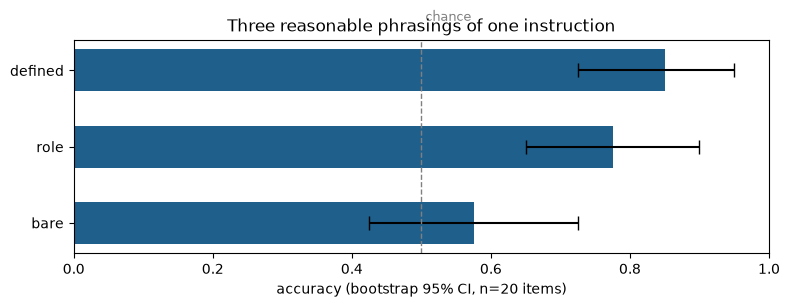

In [17]:
fig, ax = plt.subplots(figsize=(8, 3.2))
order = sorted(cis, key=lambda p: cis[p][0])
ys = np.arange(len(order))
means = [cis[p][0] for p in order]
lo = [cis[p][0] - cis[p][1] for p in order]
hi = [cis[p][2] - cis[p][0] for p in order]
ax.barh(ys, means, color="#1f5f8b", xerr=[lo, hi], capsize=5, height=.55)
ax.set_yticks(ys); ax.set_yticklabels(order)
ax.axvline(0.5, ls="--", c="gray", lw=1)
ax.text(0.5, len(order)-0.35, " chance", fontsize=9, color="gray")
ax.set_xlim(0, 1); ax.set_xlabel("accuracy (bootstrap 95% CI, n=20 items)")
ax.set_title("Three reasonable phrasings of one instruction")
plt.tight_layout(); plt.show()

### Step 3.5 — ✅ CHECKPOINT C

**Post the two spreads and the ratio.**

In [18]:
ratio = PROMPT_SPREAD / SEED_SPREAD if SEED_SPREAD > 0 else float("inf")

print("=" * 58)
print("  CHECKPOINT C — prompt sensitivity")
print("=" * 58)
print(f"  spread across prompts : {PROMPT_SPREAD:.3f}")
print(f"  spread across seeds   : {SEED_SPREAD:.3f}")
print(f"  ratio                 : {ratio:.1f}x" if np.isfinite(ratio)
      else "  ratio                 : infinite (seeds were identical)")
print(f"  best / worst prompt   : {by_prompt.idxmax()} / {by_prompt.idxmin()}")
print("=" * 58)
print("\n  ^ post these to the shared sheet")

  CHECKPOINT C — prompt sensitivity
  spread across prompts : 0.275
  spread across seeds   : 0.050
  ratio                 : 5.5x
  best / worst prompt   : defined / bare

  ^ post these to the shared sheet


### Where this leaves you

Whatever your numbers, the structural point holds and is worth stating carefully:

**A published comparison of two models, each run with one prompt, is confounded.** The
difference you see is the model effect *plus* the prompt effect, and nothing in the paper lets
you separate them. Prompt phrasing is rarely reported, never randomised, and frequently tuned
harder for one condition than the other.

In your own work, the defensible minimum is: report the exact prompt, run more than one
phrasing, and show the spread.

---

## Part 4 — Is the model's confidence worth anything?

### Step 4.1 — What we are testing

The schema asked for a `confidence` between 0 and 1 on every call, so you already have it —
no extra generation needed.

**The question.** If the model says 0.9, is it right about 90% of the time?

**Why this matters.** People use these numbers to triage: auto-accept above 0.9, review the
rest. If the number is not calibrated, that workflow is quietly broken and you will not find
out from the workflow itself.

**What you should see.** The distribution of stated confidences. Look at it before the chart —
the shape alone tells you most of the story.

In [19]:
conf = grid.dropna(subset=["conf"])

# How many calls answered on the wrong scale? This is the schema's blind spot
# from Step 2.1, measured on your own data.
if "conf_raw" in grid.columns:
    _raw = pd.to_numeric(grid["conf_raw"], errors="coerce")
    _n = int((_raw > 1.0).sum())
    if _n:
        print(f"note: {_n} of {int(_raw.notna().sum())} calls answered confidence on a")
        print(f"      0-100 scale and were normalised by conf01(). The schema pinned")
        print(f"      the type, not the range — Step 2.1.\n")
    else:
        print("all calls answered confidence on a 0-1 scale this time\n")

print(conf.conf.describe().round(3).to_string())
print(f"\ndistinct confidence values used: {conf.conf.nunique()}")
print(conf.conf.value_counts().head(8).to_string())

note: 8 of 119 calls answered confidence on a
      0-100 scale and were normalised by conf01(). The schema pinned
      the type, not the range — Step 2.1.

count    119.000
mean       0.918
std        0.073
min        0.700
25%        0.900
50%        0.950
75%        0.950
max        1.000

distinct confidence values used: 7
conf
0.95    62
1.00    19
0.80    15
0.85     9
0.90     9
0.75     3
0.70     2


### Step 4.2 — The reliability diagram

**What this does.** Bins predictions by stated confidence and plots, for each bin, the mean
stated confidence against the observed accuracy.

**How to read it.** Perfect calibration is the diagonal. Points **below** the line mean
overconfidence: it claimed 0.9 and delivered less. The number next to each point is how many
predictions fell in that bin — ignore bins with very few.

**ECE** (expected calibration error) summarises the gap: the average distance from the
diagonal, weighted by bin size. Lower is better; 0 is perfect.

**What you will probably see.** Everything piled at 0.9 or 0.95, including the wrong answers.
Small models tend to state high confidence almost regardless of whether they are right — that
is a stylistic habit learned from training text, not a probability.

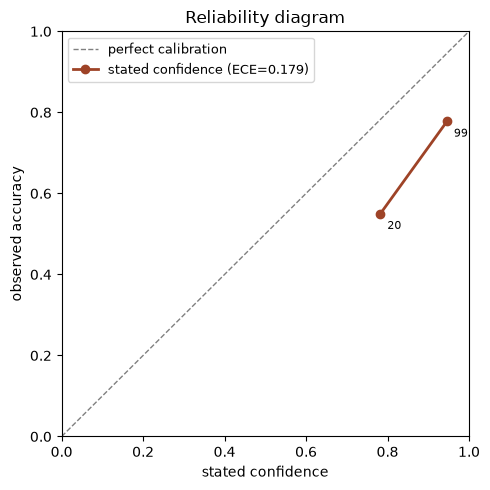

Expected Calibration Error: 0.179
mean stated confidence     : 0.918
actual accuracy            : 0.739
overconfidence gap         : +0.179


In [20]:
def reliability(c, y, n_bins=6):
    c, y = np.asarray(c, float), np.asarray(y, float)
    m = ~np.isnan(c); c, y = c[m], y[m]
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, ns = [], [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        sel = (c >= lo) & ((c < hi) if hi < 1 else (c <= hi))
        if sel.sum():
            xs.append(c[sel].mean()); ys.append(y[sel].mean()); ns.append(int(sel.sum()))
    ece = sum(n * abs(x - y_) for x, y_, n in zip(xs, ys, ns)) / max(sum(ns), 1)
    return np.array(xs), np.array(ys), np.array(ns), ece

x, y, n, ECE = reliability(conf.conf, conf.correct)

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], "--", c="gray", lw=1, label="perfect calibration")
ax.plot(x, y, "o-", c="#9e4327", lw=2, label=f"stated confidence (ECE={ECE:.3f})")
for xi, yi, ni in zip(x, y, n):
    ax.annotate(str(ni), (xi, yi), textcoords="offset points", xytext=(5, -11), fontsize=8)
ax.set_xlabel("stated confidence"); ax.set_ylabel("observed accuracy")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.legend(loc="upper left", fontsize=9)
ax.set_title("Reliability diagram")
plt.tight_layout(); plt.show()

print(f"Expected Calibration Error: {ECE:.3f}")
print(f"mean stated confidence     : {conf.conf.mean():.3f}")
print(f"actual accuracy            : {conf.correct.mean():.3f}")
print(f"overconfidence gap         : {conf.conf.mean() - conf.correct.mean():+.3f}")

### Step 4.3 — A confidence measure that does work

**What this does.** Ignores what the model *said* and instead uses how often it *agrees with
itself*.

**The idea.** You already ran every item under 3 prompts × 2 seeds — six independent-ish
opinions per sentence. The fraction voting for the winning label is a confidence estimate that
costs you nothing extra, because the calls are already made.

**Why it tends to beat stated confidence.** The model is not reporting anything when it writes
0.95 — it is producing a plausible-looking token. Agreement across conditions is a measurement
of something real: how stable the answer is to things that should not have mattered.

**What you should see.** A second calibration figure, and a comparison of the two ECEs.

**This is also a preview of Week 10**, where self-consistency becomes one of the cheap
evaluation tools.

In [21]:
vote = (grid.dropna(subset=["pred"])
             .groupby("sentence")
             .agg(gold=("gold", "first"),
                  n=("pred", "size"),
                  top=("pred", lambda s: s.value_counts().idxmax()),
                  agree=("pred", lambda s: s.value_counts().iloc[0] / len(s))))
vote["correct"] = vote.top == vote.gold

x2, y2, n2, ECE2 = reliability(vote.agree, vote.correct, n_bins=4)

print(f"majority-vote accuracy : {vote.correct.mean():.3f}")
print(f"mean single-run accuracy: {grid.correct.mean():.3f}")
print()
print(f"ECE, stated confidence  : {ECE:.3f}")
print(f"ECE, agreement across 6 : {ECE2:.3f}")
print()
print("agreement vs accuracy:")
for xi, yi, ni in zip(x2, y2, n2):
    print(f"   agreement {xi:.2f}  ->  accuracy {yi:.2f}   (n={ni})")

majority-vote accuracy : 0.850
mean single-run accuracy: 0.733

ECE, stated confidence  : 0.179
ECE, agreement across 6 : 0.108

agreement vs accuracy:
   agreement 0.67  ->  accuracy 0.80   (n=10)
   agreement 0.98  ->  accuracy 0.90   (n=10)


### Step 4.4 — ✅ CHECKPOINT D

**Post both ECE values.**

In [22]:
print("=" * 58)
print("  CHECKPOINT D — calibration")
print("=" * 58)
print(f"  mean stated confidence     : {conf.conf.mean():.3f}")
print(f"  actual accuracy            : {conf.correct.mean():.3f}")
print(f"  ECE, stated confidence     : {ECE:.3f}")
print(f"  ECE, agreement across runs : {ECE2:.3f}")
print("=" * 58)
print("\n  ^ post both ECE values to the shared sheet")

  CHECKPOINT D — calibration
  mean stated confidence     : 0.918
  actual accuracy            : 0.739
  ECE, stated confidence     : 0.179
  ECE, agreement across runs : 0.108

  ^ post both ECE values to the shared sheet


---

## What to take from today

**1. A schema is not a formatting preference — it is an instrument.** Constrained decoding
removes the parsing layer, and with it a silent failure mode that biases your data. Use it for
every extraction, classification and judgement task from here on.

**2. Prompt phrasing is an experimental factor.** It is chosen by the researcher, it moves the
result, and it is almost never reported. Comparing two models on one prompt each does not
isolate the model.

**3. Stated confidence is not a probability.** If you need a usable confidence, measure
agreement across conditions instead — you are usually running those calls anyway.

**4. Twenty items is not enough to rank anything.** Your intervals overlapped. That is the
correct conclusion at this sample size, and it is why Week 10 exists.

---

## Optional — only if Part 0 said your machine is fast enough

### Extension A — does a bigger model change the conclusion?

**What this tests.** Whether the prompt spread you measured is a property of *small* models or
of the method.

**Set up first** in a terminal: `ollama pull phi4-mini` (about 2.5 GB), then set the model name
below and run.

**How long.** 120 more calls on a slower model. Only attempt this if you are above ~30 tok/s,
or run it at home.

In [23]:
BIG_MODEL = "qwen3:8b"     # >>> EDIT: e.g. "phi4-mini" — after pulling it

if BIG_MODEL and RUN_OPTIONAL:
    recs = []
    total = len(PROMPTS) * len(df); n = 0
    for pname, tmpl in PROMPTS.items():
        for r in df.itertuples():
            txt, _ = llm(tmpl.format(s=r.sentence), model=BIG_MODEL,
                         seed=0, fmt=SCHEMA, max_tokens=120, **SAMPLING)
            try: pred = json.loads(txt)["label"]
            except Exception: pred = None
            recs.append({"prompt": pname, "gold": r.label, "pred": pred})
            n += 1; print(f"  {n}/{total}", end="\r", flush=True)
    big = pd.DataFrame(recs); big["correct"] = big.pred == big.gold
    bp = big.groupby("prompt").correct.mean()
    print(f"\n\n{BIG_MODEL}:")
    print(bp.round(3).to_string())
    print(f"\nprompt spread, {BIG_MODEL:12s}: {bp.max()-bp.min():.3f}")
    print(f"prompt spread, {MODEL:12s}: {PROMPT_SPREAD:.3f}")
    print(f"\nmodel difference (best prompt each): {bp.max() - by_prompt.max():+.3f}")
    print("\nCompare that model difference against the prompt spread above.")
    print("If the prompt spread is larger, then 'model A beats model B' is not")
    print("a claim this experiment can support.")
else:
    print("Skipped. Set BIG_MODEL after pulling a second model, and make sure")
    print("Part 0 reported your machine as fast enough.")

  60/60

qwen3:8b:
prompt
bare       0.80
defined    0.90
role       0.75

prompt spread, qwen3:8b    : 0.150
prompt spread, qwen3:1.7b  : 0.275

model difference (best prompt each): +0.050

Compare that model difference against the prompt spread above.
If the prompt spread is larger, then 'model A beats model B' is not
a claim this experiment can support.


### Extension B — few-shot examples

**What this tests.** Whether showing the model two worked examples moves accuracy more than
rephrasing the instruction did.

**Why it is interesting.** Few-shot prompting is the most commonly recommended technique in
practice. Here you get to check whether it earns its tokens on your task, against a measured
baseline rather than against an impression.

**How long.** 20 calls.

In [24]:
FEWSHOT = (
  "Classify each sentence as causal or assoc.\n\n"
  "Sentence: Aspirin lowers the risk of stroke.\n"
  "Answer: causal  (cue: 'lowers', asserts production)\n\n"
  "Sentence: Stroke risk is lower among aspirin users.\n"
  "Answer: assoc  (cue: 'among', reports a relationship)\n\n"
  "Now classify this sentence, reporting label, cue and confidence.\n"
  "Sentence: {s}"
)

if RUN_OPTIONAL:
    recs = []
    for i, r in enumerate(df.itertuples(), 1):
        txt, _ = llm(FEWSHOT.format(s=r.sentence), seed=0, fmt=SCHEMA, max_tokens=120,
                     **SAMPLING)
        try: pred = json.loads(txt)["label"]
        except Exception: pred = None
        recs.append({"gold": r.label, "pred": pred})
        print(f"  {i}/{len(df)}", end="\r", flush=True)
    fs = pd.DataFrame(recs); fs["correct"] = fs.pred == fs.gold
    m, lo, hi = boot_ci(fs.correct.values)
    print(f"\n\nfew-shot accuracy : {m:.3f}  [{lo:.3f}, {hi:.3f}]")
    print(f"best zero-shot    : {by_prompt.max():.3f}")
    print(f"difference        : {m - by_prompt.max():+.3f}")
    print("\nIs that difference outside the intervals from Step 3.4?")
    print("If not, few-shot did not measurably help here — at this sample size.")
else:
    print("Skipped — Part 0 reported your machine is better used on the core lab.")

  20/20

few-shot accuracy : 0.800  [0.600, 0.950]
best zero-shot    : 0.850
difference        : -0.050

Is that difference outside the intervals from Step 3.4?
If not, few-shot did not measurably help here — at this sample size.


---

## Before you close

- [ ] Four checkpoint numbers posted to the shared sheet
- [ ] `w2_grid.csv` saved in your project folder (you will not need it again, but it means
      you can re-open this notebook without re-running anything)

### Next session

**Session 3 — AI Data Acquisition Pipelines.** You build a pipeline that fetches web pages,
cleans them, and extracts structured records using exactly the schema technique from Part 2 —
and then measures how often the extraction is wrong.

That session is where your group-project data comes from, so it matters more than most.

**Before then:** have a look around for a data source relevant to your own work — an archive, a
registry, a set of documents, a site with records you care about. No commitment yet; just start
noticing what exists.